In [35]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

Para el TFG no se necesita ver como cambia en el eje Y de las rodillas, sino como en la pierna se dobla en grados, y para ello hay que tener en cuenta los tobillos, rodilla y cadera. Pero importante es normalizar todo entre el ancho de cadera, ya que cada video puede variar en funcion del eje z.

In [36]:
CSV_FOLDER = Path(r"C:\Users\david\Desktop\Results\datos_csv") 

csv_files = sorted(list(CSV_FOLDER.glob('*.csv')))[:8]

In [37]:
def calculate_angle(a, b, c):
    
    # We transform the lists to numpy arrays
    a = np.array(a) # Coordinates of the hip [x, y]
    b = np.array(b) # Coordinates of the knee [x,y]
    c = np.array(c) # Coordinates of the anke [x, y]
    
    ba = a - b
    bc = c - b
    
    # We calculate the dot product
    dot_product = np.dot(ba, bc)
    
    # We calculate the magnitudes
    norm_ba = np.linalg.norm(ba)
    norm_bc = np.linalg.norm(bc)
    
    # We calculate the cosine
    cosine_angle = dot_product / (norm_ba * norm_bc)
    
    # We force it to some values
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)
    
    # We calculate the arccos
    angle_radians = np.arccos(cosine_angle)

    # We convert it to degrees
    angle_degrees = np.degrees(angle_radians)

    return angle_degrees

Procesando (1/8): flat_pinpoint_103_landmarks.csv...
Procesando (2/8): flat_pinpoint_107_landmarks.csv...
Procesando (3/8): flat_pinpoint_113_landmarks.csv...
Procesando (4/8): flat_pinpoint_115_landmarks.csv...
Procesando (5/8): flat_pinpoint_116_landmarks.csv...
Procesando (6/8): flat_pinpoint_126_landmarks.csv...
Procesando (7/8): flat_pinpoint_127_landmarks.csv...
Procesando (8/8): flat_pinpoint_132_landmarks.csv...


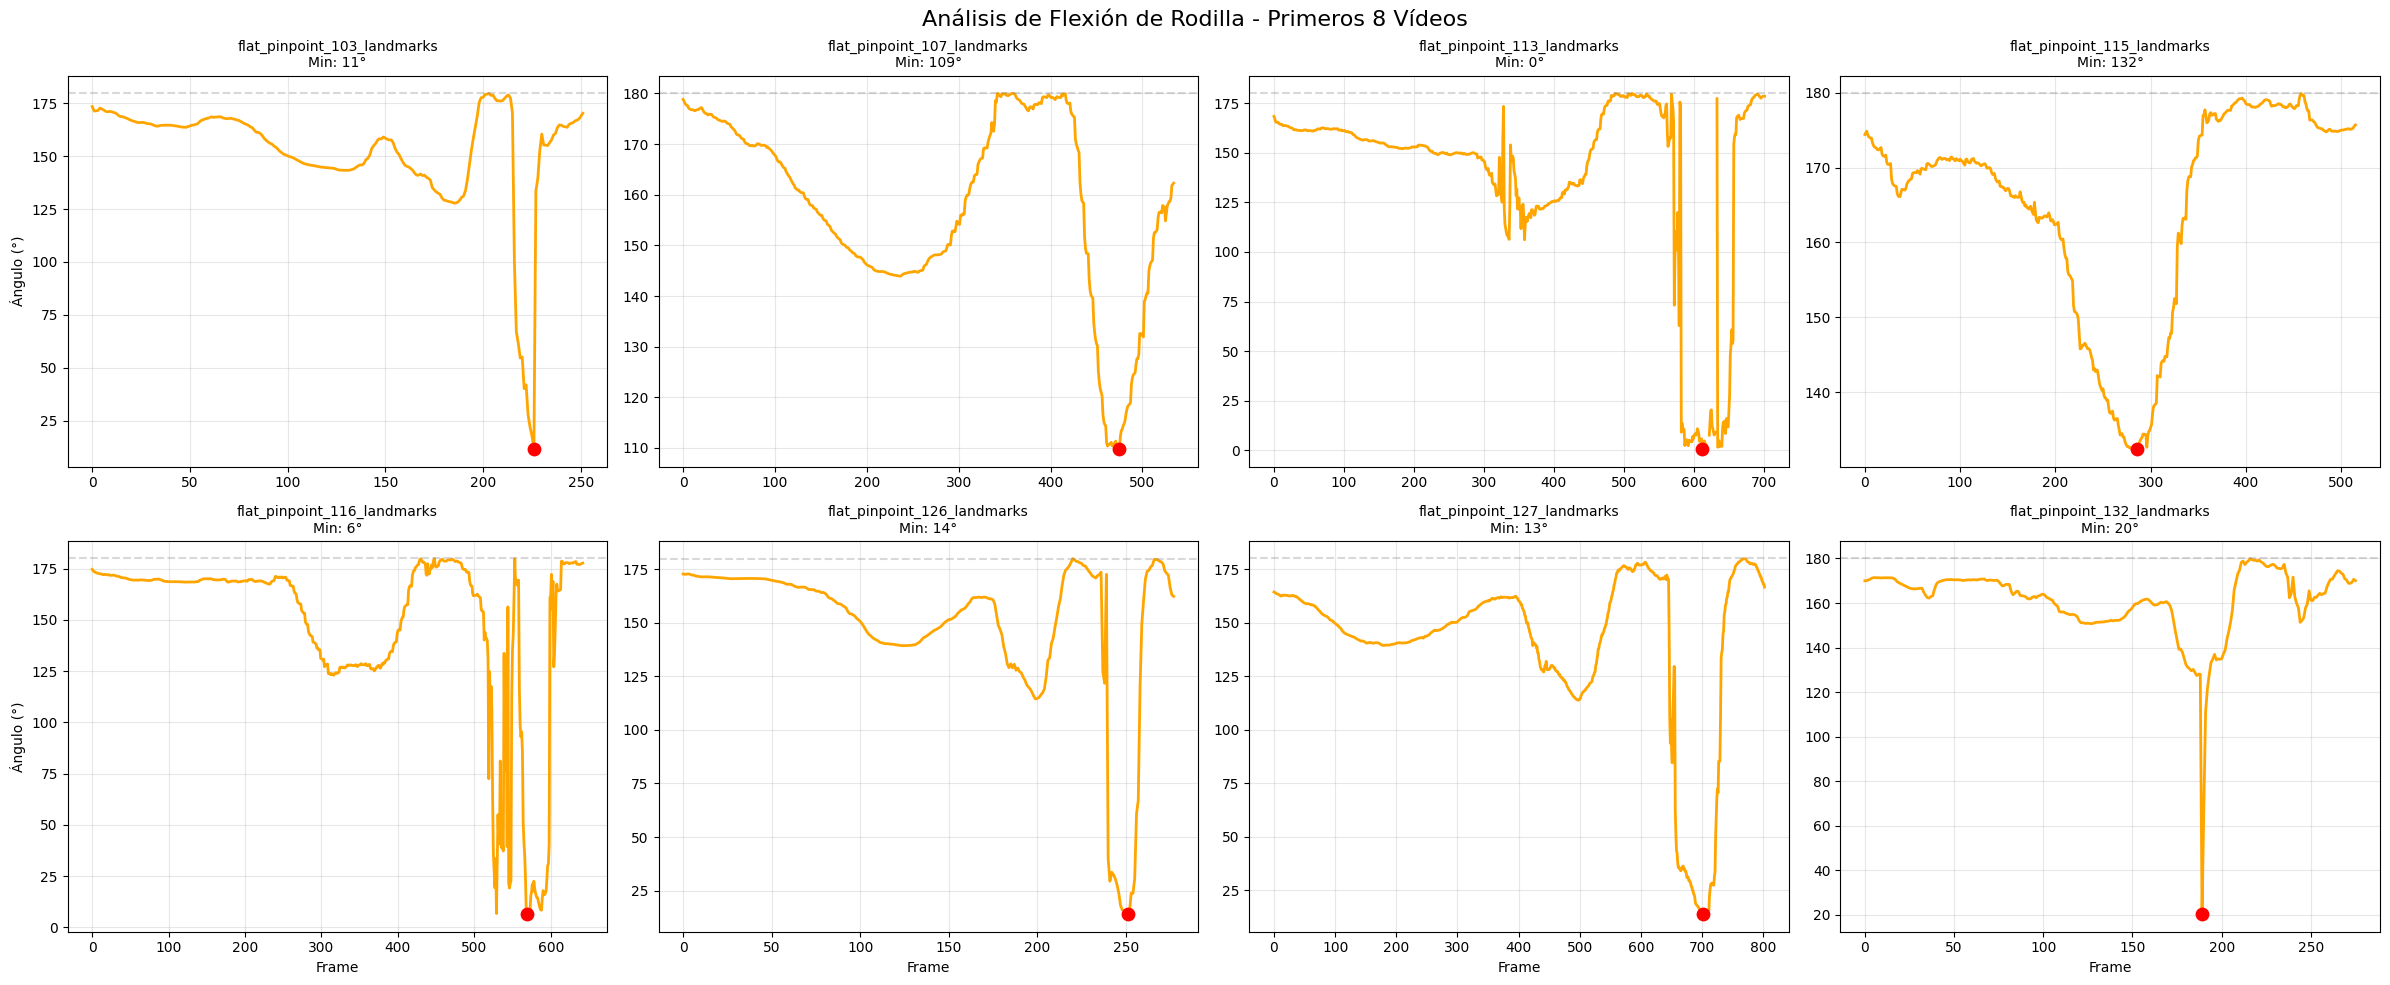

In [38]:
# --- 3. PREPARAR EL GRÁFICO (GRID 2 filas x 4 columnas) ---
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente (0 a 7)

for idx, file_path in enumerate(csv_files):
    print(f"Procesando ({idx+1}/8): {file_path.name}...")
    
    try:
        df = pd.read_csv(file_path)
        
        angulos_rodilla = []
        for i in range(len(df)):
            cadera = [df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']]
            rodilla = [df.loc[i, 'RIGHT_KNEE_x'], df.loc[i, 'RIGHT_KNEE_y']]
            tobillo = [df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']]
            
            angulo = calculate_angle(cadera, rodilla, tobillo)
            angulos_rodilla.append(angulo)
        
        df['angulo_rodilla'] = angulos_rodilla
        
        # --- ESTADÍSTICAS CLAVE ---
        min_flexion_val = df['angulo_rodilla'].min()
        min_flexion_frame = df['angulo_rodilla'].idxmin()
        
        # --- PINTAR EN SU SUB-GRÁFICA CORRESPONDIENTE ---
        ax = axes[idx] # Seleccionamos el recuadro actual
        
        # Línea del ángulo
        ax.plot(df['frame_id'], df['angulo_rodilla'], color='orange', linewidth=2)
        
        # Punto de máxima carga
        ax.scatter(df.loc[min_flexion_frame, 'frame_id'], min_flexion_val, color='red', s=80, zorder=5)
        
        # Decoración
        ax.set_title(f"{file_path.stem}\nMin: {int(min_flexion_val)}°", fontsize=10)
        ax.axhline(y=180, color='gray', linestyle='--', alpha=0.3) # Referencia recta
        ax.grid(True, alpha=0.3)
        
        # Solo ponemos etiquetas en los bordes para no ensuciar
        if idx % 4 == 0:
            ax.set_ylabel("Ángulo (°)")
        if idx >= 4:
            ax.set_xlabel("Frame")
            
    except Exception as e:
        print(f"⚠️ Error con {file_path.name}: {e}")


plt.suptitle("Análisis de Flexión de Rodilla - Primeros 8 Vídeos", fontsize=16)
plt.tight_layout()
plt.show()

COMPARACION RIGHT_KNEE Y LEFT_KNEE

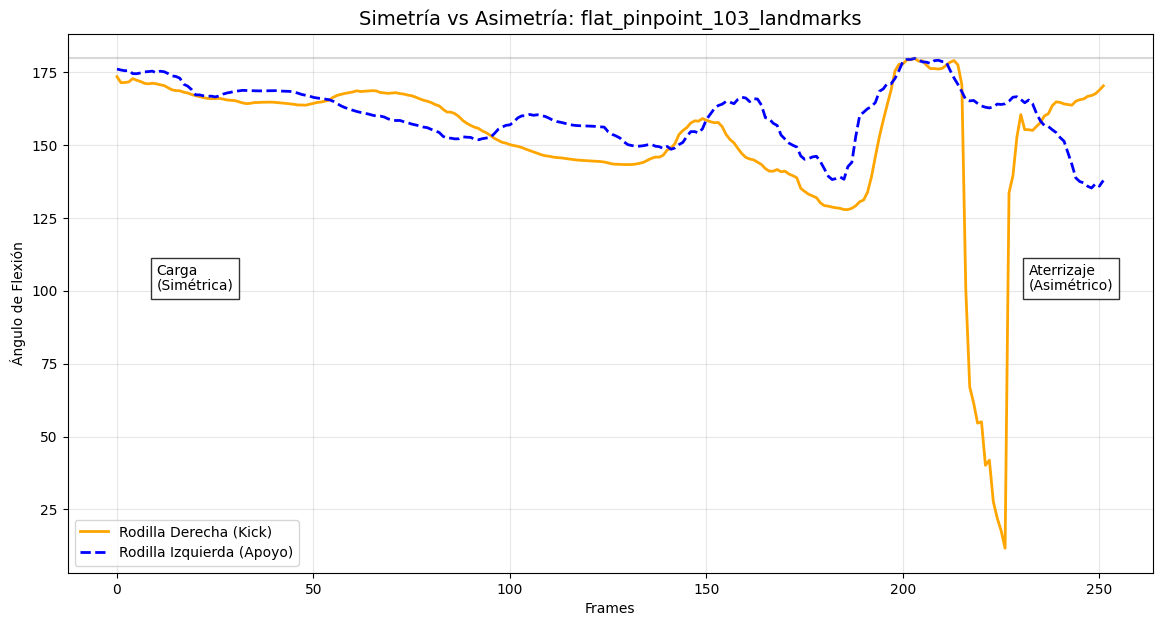

In [ ]:
file_path = csv_files[0] 
df = pd.read_csv(file_path)

angulos_derecha = []
angulos_izquierda = []

for i in range(len(df)):
    # --- LADO DERECHO (Right) ---
    r_hip = [df.loc[i, 'RIGHT_HIP_x'], df.loc[i, 'RIGHT_HIP_y']]
    r_knee = [df.loc[i, 'RIGHT_KNEE_x'], df.loc[i, 'RIGHT_KNEE_y']]
    r_ankle = [df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']]
    angulos_derecha.append(calculate_angle(r_hip, r_knee, r_ankle))
    
    # --- LADO IZQUIERDO (Left) ---
    l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
    l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
    l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
    angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))

# --- VISUALIZACIÓN COMPARATIVA ---
plt.figure(figsize=(14, 7))

# Gráfica Derecha (Naranja)
plt.plot(df['frame_id'], angulos_derecha, color='orange', label='Rodilla Derecha (Kick)', linewidth=2)

# Gráfica Izquierda (Azul)
plt.plot(df['frame_id'], angulos_izquierda, color='blue', label='Rodilla Izquierda (Apoyo)', linewidth=2, linestyle='--')

# Decoración
plt.title(f"Simetría vs Asimetría: {file_path.stem}", fontsize=14)
plt.xlabel("Frames")
plt.ylabel("Ángulo de Flexión")
plt.axhline(y=180, color='gray', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)

# Identificar zonas clave visualmente
plt.text(10, 100, "Carga\n(Simétrica)", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(len(df)-20, 100, "Aterrizaje\n(Asimétrico)", fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

Analizamos todo con el RIGHT_KNEE

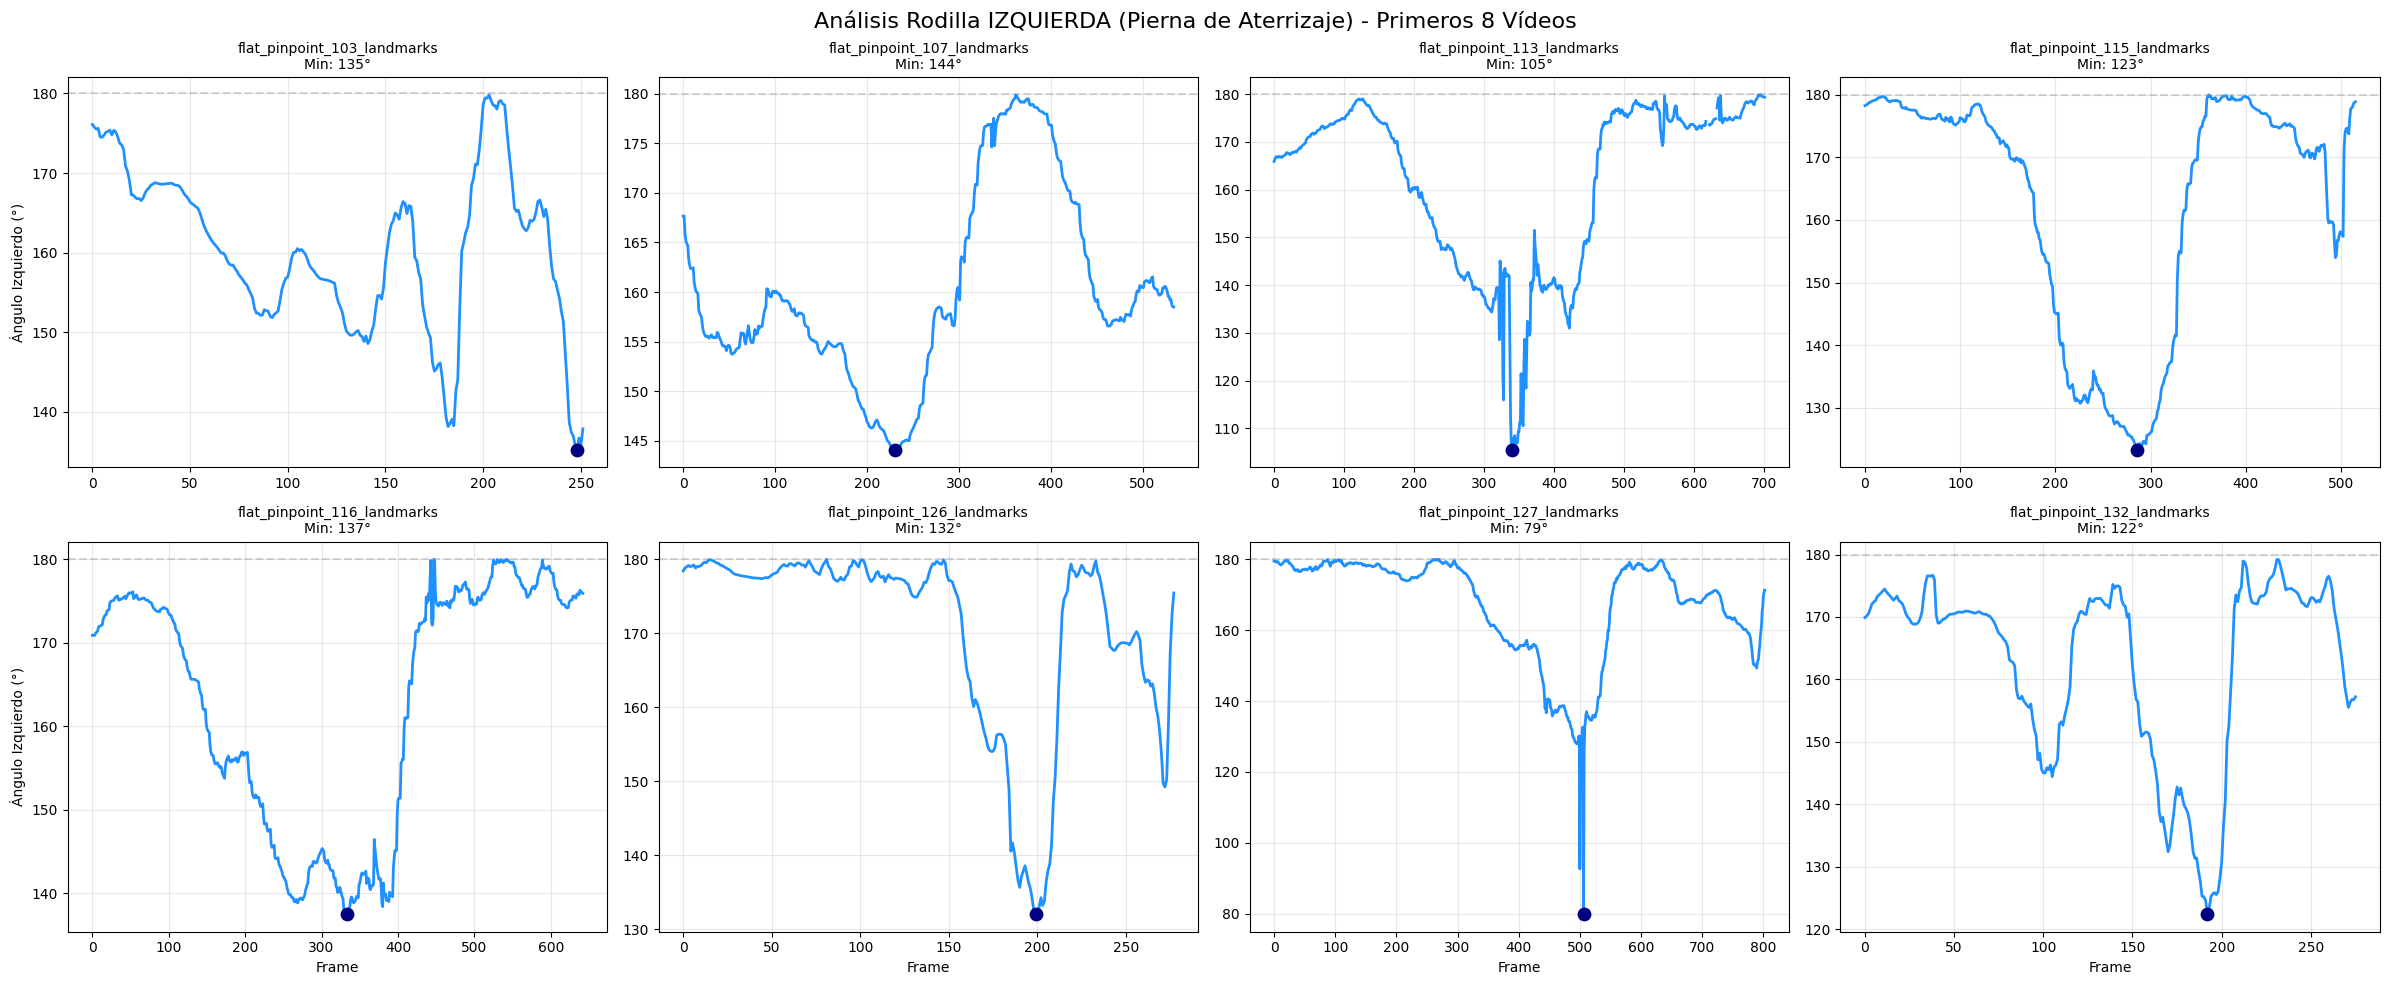

In [41]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten() 

for idx, file_path in enumerate(csv_files):
    try:
        df = pd.read_csv(file_path)
        
        angulos_izquierda = []
        for i in range(len(df)):
            # --- CAMBIO CLAVE: AHORA USAMOS 'LEFT' ---
            cadera = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            rodilla = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            tobillo = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            
            angulo = calculate_angle(cadera, rodilla, tobillo)
            angulos_izquierda.append(angulo)
        
        df['angulo_rodilla_izq'] = angulos_izquierda
        
        # --- ESTADÍSTICAS ---
        min_val = df['angulo_rodilla_izq'].min()
        min_frame = df['angulo_rodilla_izq'].idxmin()
        
        # --- PINTAR ---
        ax = axes[idx] 
        # Usamos azul para diferenciar visualmente de la derecha (que era naranja)
        ax.plot(df['frame_id'], df['angulo_rodilla_izq'], color='dodgerblue', linewidth=2)
        
        # Punto de máxima flexión
        ax.scatter(df.loc[min_frame, 'frame_id'], min_val, color='navy', s=80, zorder=5)
        
        # Decoración
        ax.set_title(f"{file_path.stem}\nMin: {int(min_val)}°", fontsize=10)
        ax.axhline(y=180, color='gray', linestyle='--', alpha=0.3)
        ax.grid(True, alpha=0.3)
        
        if idx % 4 == 0:
            ax.set_ylabel("Ángulo Izquierdo (°)")
        if idx >= 4:
            ax.set_xlabel("Frame")
            
    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

# --- 5. MOSTRAR RESULTADO ---
plt.suptitle("Análisis Rodilla IZQUIERDA (Pierna de Aterrizaje) - Primeros 8 Vídeos", fontsize=16)
plt.tight_layout()
plt.show()

Una vez comprobado que es mejor usar el LEFT_KNEE, marcamos el punto minimo (en el lazo iquierdo del punto maximo), y marcamos el punto máximo. Y por último, marcamos el punto medio, y obtenemos el valor de ese punto, que será el frame que estamos buscando.

⚠️ Usando simulación para demostrar el filtro.


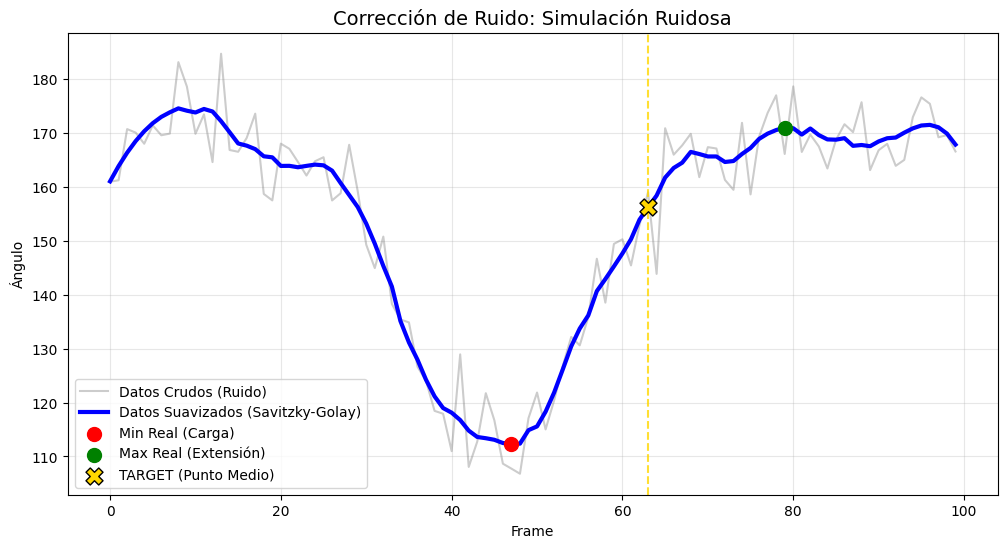

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter # <--- LA CLAVE MÁGICA

# --- 1. CARGAMOS TUS DATOS ---
# Usamos el CSV real si existe, si no, simulación con ruido para el ejemplo
try:
    df = pd.read_csv('flat_pinpoint_103_landmarks.csv')
    filename = 'flat_pinpoint_103_landmarks.csv'
except:
    print("⚠️ Usando simulación para demostrar el filtro.")
    frames = np.arange(0, 100)
    # Simulo curva con MUCHO RUIDO para que veas el problema
    ruido = np.random.normal(0, 5, 100) 
    curva_real = 170 - 60 * np.exp(-0.005 * (frames - 45)**2) # Mínimo real en 45
    angles = curva_real + ruido
    df = pd.DataFrame({'frame_id': frames})
    filename = 'Simulación Ruidosa'

# --- 2. CALCULAR ÁNGULOS CRUDOS ---
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc = a - b, c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

if 'LEFT_KNEE_x' in df.columns:
    angles_left = []
    for i in range(len(df)):
        l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
        l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
        l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
        angles_left.append(calculate_angle(l_hip, l_knee, l_ankle))
    df['angle_raw'] = angles_left
else:
    df['angle_raw'] = angles

# --- 3. APLICAR FILTRO DE SUAVIZADO (FIX) ---
# window_length: Cuántos frames miro a la vez (debe ser impar). 
# Cuanto más alto, más suave la curva, pero pierdes detalle rápido.
# polyorder: Grado del polinomio (3 suele ir bien para movimiento humano).
df['angle_smooth'] = savgol_filter(df['angle_raw'], window_length=15, polyorder=3)

# --- 4. BUSCAR MIN/MAX SOBRE LA CURVA SUAVIZADA ---

# A) Mínimo (Squat / Carga)
# Buscamos en la primera mitad del video aprox
search_limit = int(len(df) * 0.7)
frame_min = df['angle_smooth'][:search_limit].idxmin()
val_min = df.loc[frame_min, 'angle_smooth']

# B) Máximo (Despegue / Extensión)
# Buscamos DESPUÉS del mínimo
search_range = df['angle_smooth'][frame_min:search_limit + 25] # +25 frames margen
frame_max = search_range.idxmax()
val_max = df.loc[frame_max, 'angle_smooth']

# C) Target (La Media)
target_frame = int((frame_min + frame_max) / 2)
val_target = df.loc[target_frame, 'angle_smooth'] # Valor en la curva suave

# --- 5. VISUALIZACIÓN COMPARATIVA ---
plt.figure(figsize=(12, 6))

# Pintamos los datos CRUDOS (con ruido) en gris clarito
plt.plot(df['frame_id'], df['angle_raw'], color='gray', alpha=0.4, label='Datos Crudos (Ruido)')

# Pintamos los datos SUAVIZADOS (Realidad Biomecánica) en azul fuerte
plt.plot(df['frame_id'], df['angle_smooth'], color='blue', linewidth=3, label='Datos Suavizados (Savitzky-Golay)')

# Marcamos los puntos CALCULADOS SOBRE LA SUAVE
plt.scatter(df.loc[frame_min, 'frame_id'], val_min, color='red', s=100, zorder=5, label='Min Real (Carga)')
plt.scatter(df.loc[frame_max, 'frame_id'], val_max, color='green', s=100, zorder=5, label='Max Real (Extensión)')
plt.scatter(df.loc[target_frame, 'frame_id'], val_target, color='gold', edgecolor='black', s=150, marker='X', zorder=10, label='TARGET (Punto Medio)')

plt.axvline(x=df.loc[target_frame, 'frame_id'], color='gold', linestyle='--', alpha=0.8)

plt.title(f"Corrección de Ruido: {filename}", fontsize=14)
plt.xlabel("Frame")
plt.ylabel("Ángulo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()